<a href="https://colab.research.google.com/github/desaraju02/ai_ml_dl/blob/main/HierarchicalClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Mall_Customers.csv')

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Genre'] = le.fit_transform(df['Genre'])
print(df.head())

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1      1   19                  15                      39
1           2      1   21                  15                      81
2           3      0   20                  16                       6
3           4      0   23                  16                      77
4           5      0   31                  17                      40


In [5]:
X=df.drop(['CustomerID'],axis=1)
X.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


### Using Dendrogram to find optimal number of clusters

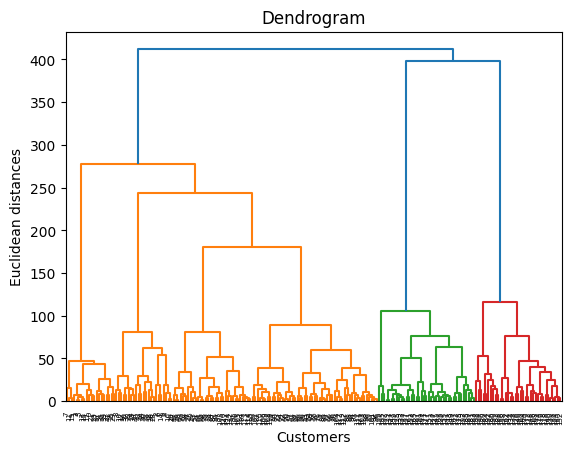

In [6]:
import scipy.cluster.hierarchy as sch
dendrogram=sch.dendrogram(sch.linkage(X,method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

### Training the Hierarchical clustering model on the dataset

In [8]:
from sklearn.cluster import AgglomerativeClustering
# Remove the affinity parameter, it's automatically set to 'euclidean' when linkage is 'ward'
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc = hc.fit_predict(X)

### Visualizing

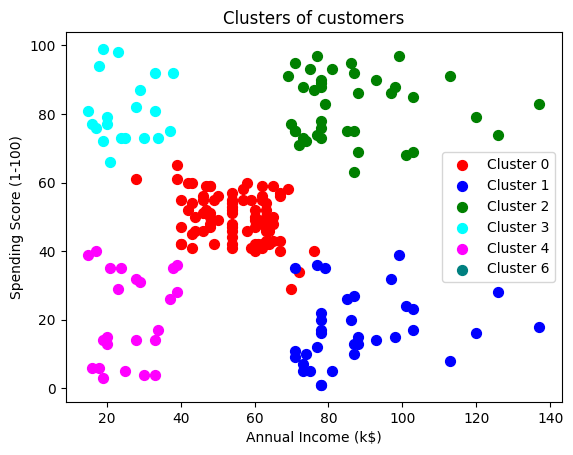

In [10]:
plt.scatter(X[y_hc == 0]['Annual Income (k$)'], X[y_hc == 0]['Spending Score (1-100)'], s = 50, c = 'red', label = 'Cluster 0')
plt.scatter(X[y_hc == 1]['Annual Income (k$)'], X[y_hc == 1]['Spending Score (1-100)'], s = 50, c = 'blue', label = 'Cluster 1')
plt.scatter(X[y_hc == 2]['Annual Income (k$)'], X[y_hc == 2]['Spending Score (1-100)'], s = 50, c = 'green', label = 'Cluster 2')
plt.scatter(X[y_hc == 3]['Annual Income (k$)'], X[y_hc == 3]['Spending Score (1-100)'], s = 50, c = 'cyan', label = 'Cluster 3')
plt.scatter(X[y_hc == 4]['Annual Income (k$)'], X[y_hc == 4]['Spending Score (1-100)'], s = 50, c = 'magenta', label = 'Cluster 4')
plt.scatter(X[y_hc == 5]['Annual Income (k$)'], X[y_hc == 5]['Spending Score (1-100)'], s = 50, c = 'teal', label = 'Cluster 6')
#plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], s = 150, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()